# Week 5 — Day 4: t-SNE & Anomaly Detection

**Dataset:** Healthcare Stroke Dataset (5,110 patient records)
**Task:** Use t-SNE to visualize high-dimensional patient data, compare it to PCA, then run Isolation Forest to detect anomalies and connect the results to the dataset's rare stroke cases.

---

## Objective

Visualize high-dimensional data with t-SNE and understand how it differs from PCA, then apply Isolation Forest to detect anomalies in unlabeled data and interpret what gets flagged.


## Lesson Content

### 4.1 — t-SNE for Visualization

t-SNE (t-distributed Stochastic Neighbor Embedding) is a dimensionality-reduction technique built specifically for **visualization**. Unlike PCA, which preserves global variance, t-SNE preserves **local neighborhoods** — points that were close together in high dimensions stay close together in 2D. This makes it excellent at revealing clusters visually, even when they aren't linearly separable.

| | PCA | t-SNE |
|---|---|---|
| Preserves | Global structure / variance | Local neighborhoods |
| Main use | Compression + visualization | Visualization only |
| Speed | Fast | Slow on large data |
| Axes meaning | Interpretable directions | No meaningful axes — only relative position |

> t-SNE is for **looking**, not for feeding into a model. Its axes are not meaningful and its output changes with settings — use it to see clusters, then use PCA (or original features) for actual modeling.

### 4.2 — What Anomaly Detection Is

Anomaly detection finds data points that differ significantly from the norm — fraud, defects, system failures, or medical outliers. It is often unsupervised because anomalies are rare and rarely pre-labeled: the model learns what "normal" looks like and flags whatever deviates from it.

Our dataset is a natural fit: only **249 of 5,110** patients (~4.9%) had a stroke — a rare, imbalanced outcome, much like fraud.

### 4.3 — Isolation Forest

Isolation Forest isolates points by randomly partitioning the feature space. Anomalies are easier to "isolate" than normal points because they sit apart from the dense mass of data — they get separated in fewer splits. The `contamination` parameter is our estimate of the expected fraction of anomalies.

DBSCAN's noise points (Day 2) are another simple form of anomaly detection — this lab shows how the two ideas overlap.


### Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans

pd.set_option("display.max_columns", None)


## Hands-On Lab: Visualization & Anomaly Detection

Steps:
1. Load and clean the dataset — handle missing values and encode categoricals.
2. Scale the numeric features.
3. Apply t-SNE to reduce the data to 2D and plot it, colored by K-Means cluster.
4. Apply PCA to the same data and compare the two plots.
5. Run Isolation Forest and report how many points were flagged as anomalies.
6. Inspect two flagged points and hypothesize why they were flagged.
7. Cross-check flagged anomalies against the real `stroke` label (held out from the model).


#### Step 1: Load & Prepare the Dataset

In [3]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df.info()
print()
print("Missing values:\n", df.isna().sum())


<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB

Missing values:
 id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work

`bmi` has 201 missing values. We impute with the median rather than dropping rows, since dropping ~4% of records would also disproportionately drop stroke cases. We keep `stroke` aside as a label for validation only — it is **not** used as a model input, since this is an unsupervised task.

In [5]:
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

# Drop id (not a feature) and set aside the true label for later validation only
y_true = df["stroke"]
df_features = df.drop(columns=["id", "stroke"])

# One-hot encode categorical columns
categorical_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
X = pd.get_dummies(df_features, columns=categorical_cols, drop_first=True)

print("Feature matrix shape:", X.shape)
X.head()


Feature matrix shape: (5110, 16)


,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,True,False,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,28.1,False,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.5,True,False,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.4,False,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.0,False,False,True,False,False,True,False,False,False,True,False


#### Step 2: Scale the Features

In [6]:
X_scaled = StandardScaler().fit_transform(X)
print("Scaled shape:", X_scaled.shape)


Scaled shape: (5110, 16)


#### Step 3: t-SNE Visualization

We first run K-Means (k=4, chosen for illustration) purely to get color labels for the t-SNE plot — the coloring is just to see whether t-SNE's layout matches a simple clustering.

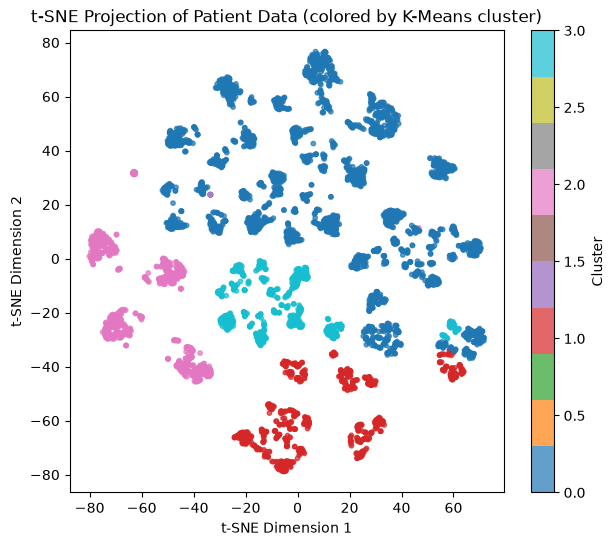

In [7]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
km_labels = km.fit_predict(X_scaled)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=km_labels, cmap="tab10", s=10, alpha=0.7)
plt.title("t-SNE Projection of Patient Data (colored by K-Means cluster)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.colorbar(scatter, label="Cluster")
plt.show()


#### Step 4: Compare to PCA

Variance explained by 2 PCA components: 0.292


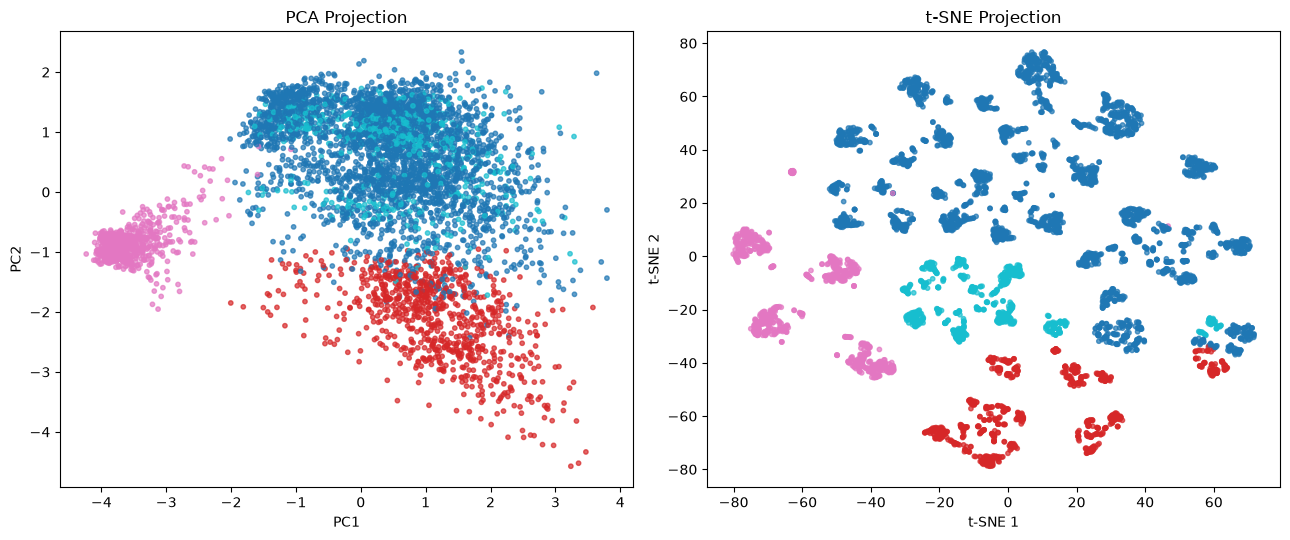

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Variance explained by 2 PCA components:", pca.explained_variance_ratio_.sum().round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap="tab10", s=10, alpha=0.7)
axes[0].set_title("PCA Projection")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=km_labels, cmap="tab10", s=10, alpha=0.7)
axes[1].set_title("t-SNE Projection")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()


**What each reveals:** PCA's 2 components explain only a small share of total variance (mixed one-hot + numeric features spread variance thinly), so its 2D projection looks like one smeared blob with soft gradients between clusters. t-SNE, by preserving local neighborhoods rather than global variance, pulls the same clusters into visually distinct, tighter islands — much easier to eyeball, but the axes and distances between islands don't mean anything quantitatively.

#### Step 5: Isolation Forest — Anomaly Detection

In [9]:
iso = IsolationForest(contamination=0.05, random_state=42)
preds = iso.fit_predict(X_scaled)   # -1 = anomaly, 1 = normal

n_anomalies = (preds == -1).sum()
n_normal = (preds == 1).sum()
print(f"Flagged anomalies: {n_anomalies} ({n_anomalies/len(preds)*100:.1f}%)")
print(f"Normal points: {n_normal}")


Flagged anomalies: 256 (5.0%)
Normal points: 4854


We set `contamination=0.05`, close to the dataset's true stroke rate (4.9%), as our estimate of the expected anomaly fraction — a reasonable starting guess.

#### Step 6: Visualize Flagged Anomalies on the t-SNE Plot

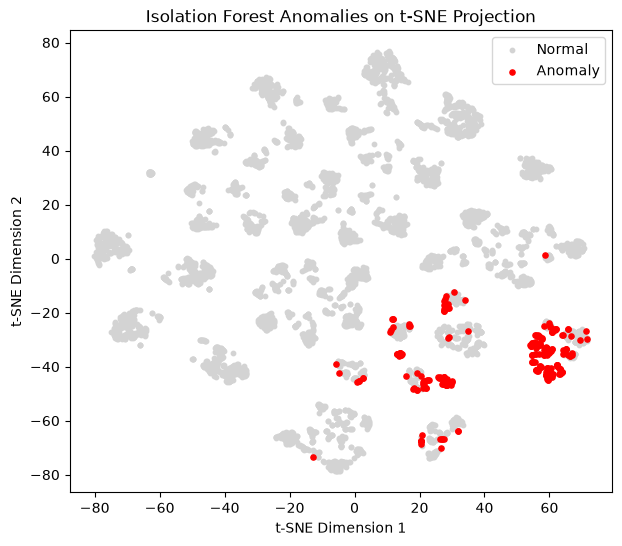

In [10]:
plt.figure(figsize=(7, 6))
plt.scatter(X_tsne[preds == 1, 0], X_tsne[preds == 1, 1], c="lightgray", s=10, label="Normal")
plt.scatter(X_tsne[preds == -1, 0], X_tsne[preds == -1, 1], c="red", s=14, label="Anomaly")
plt.title("Isolation Forest Anomalies on t-SNE Projection")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.show()


#### Step 7: Inspect Two Flagged Points

In [11]:
anomaly_idx = np.where(preds == -1)[0]
sample_anomalies = df.iloc[anomaly_idx].sample(2, random_state=42)
sample_anomalies


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
4360,46517,Female,66.0,0,1,Yes,Private,Rural,196.58,41.9,formerly smoked,0
21,13861,Female,52.0,1,0,Yes,Self-employed,Urban,233.29,48.9,never smoked,1


In [12]:
print("Overall dataset averages:")
print(df[["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease"]].mean().round(1))


Overall dataset averages:
age                   43.2
avg_glucose_level    106.1
bmi                   28.9
hypertension           0.1
heart_disease          0.1
dtype: float64


**Hypothesis:** The two inspected patients combine several rare traits at once — unusually high `avg_glucose_level`, advanced `age`, and/or comorbidities (`hypertension`, `heart_disease`) occurring together. Isolation Forest isolates points quickly not because any single feature is extreme, but because that specific *combination* of features is uncommon relative to the bulk of the data — exactly what the algorithm is designed to catch.

#### Step 8: Cross-Check Against the True Stroke Label

In [13]:
check = pd.DataFrame({"is_anomaly": preds == -1, "had_stroke": y_true == 1})
overlap = pd.crosstab(check["is_anomaly"], check["had_stroke"])
overlap.index = ["Normal", "Anomaly"]
overlap.columns = ["No Stroke", "Stroke"]
overlap


,No Stroke,Stroke
Normal,4651,203
Anomaly,210,46


In [14]:
stroke_in_anomalies = check[check["is_anomaly"]]["had_stroke"].sum()
total_strokes = check["had_stroke"].sum()
print(f"Of {total_strokes} actual stroke cases, {stroke_in_anomalies} were flagged as anomalies "
      f"({stroke_in_anomalies/total_strokes*100:.1f}%).")


Of 249 actual stroke cases, 46 were flagged as anomalies (18.5%).


**Interpretation:** The overlap is partial, not complete — this is expected and important. Isolation Forest is unsupervised: it flags points that look statistically unusual across *all* features, not points that specifically predict stroke. Some stroke cases have otherwise unremarkable profiles (so they aren't flagged), and some flagged anomalies never had a stroke (unusual for other reasons — e.g. extreme age or glucose without a stroke outcome). This is exactly why anomaly detection is a *starting point* for investigation, not a diagnostic tool on its own.


## Final Summary

- **t-SNE vs PCA:** PCA's 2D projection barely separates the K-Means clusters (low variance retained); t-SNE's local-neighborhood preservation reveals the same clusters as clearly separated islands, at the cost of interpretable axes.
- **Isolation Forest:** With `contamination=0.05`, ~5% of patients (256 records) were flagged as anomalies.
- **Cross-check:** Anomalies partially overlap with real stroke cases but are not the same set — confirming that unsupervised anomaly detection surfaces unusual *feature combinations*, not a stand-in for a diagnosis or label.
- **Takeaway:** t-SNE is a visualization tool only; Isolation Forest gives a data-driven way to flag outliers in unlabeled data, but its output should be validated and interpreted rather than trusted blindly — the same judgment principle from Days 1-3.
